In [1]:
import numpy as np
import jax.numpy as jnp

m = 15

# 1) Sample a random unitary U (via QR)
X = np.random.randn(m,m) + 1j*np.random.randn(m,m)
Q, R = np.linalg.qr(X)
# fix phases so Q is truly unitary
ph = np.exp(-1j*np.angle(np.diag(R)))
U = Q @ np.diag(ph)   # shape (m,m)

# 2) Choose three random diagonal spectra λ^(0), λ^(1), λ^(2)
#    Make each traceless by subtracting its mean
Λ0 = np.random.randn(m)
Λ0 -= Λ0.mean()
Λ1 = np.random.randn(m)
Λ1 -= Λ1.mean()
Λ2 = np.random.randn(m)
Λ2 -= Λ2.mean()

# (Optional) check they're linearly independent:
M = np.vstack([Λ0, Λ1, Λ2])
assert np.linalg.matrix_rank(M) == 3

# 3) Build H_k = U diag(Λk) U^†, and normalize
H0 = U @ np.diag(Λ0) @ U.conj().T
H1 = U @ np.diag(Λ1) @ U.conj().T
H2 = U @ np.diag(Λ2) @ U.conj().T

# 4) Normalize to unit Frobenius norm and convert for JAX
def normalize(H):
    return H / np.linalg.norm(H)

import jax
import jax.numpy as jnp
H0 = jnp.array(normalize(H0))
H1 = jnp.array(normalize(H1))
H2 = jnp.array(normalize(H2))

H_comm = jnp.stack([H0, H1, H2], axis=0)  # shape (3,15,15)


In [2]:
import jax
import jax.numpy as jnp
import numpy as np
from cymetric.pointgen.pointgen import PointGenerator

# ── Hyperparameters & setup ───────────────────────────────────────
eps = 1e-8
N = 2_000_000        # 2 million points
n_select = 200000    # number of points to keep
tol = 1e-6           # tolerance for patch isolation
chunk_size = 100_000 # for processing in chunks

# ── Generate FuncCalc quadratic Hermitian matrices (15×15) ─────────
print("=== GENERATING FUNCCALC CONSTRAINT ===")

# Generate random Hermitian A
np.random.seed(42)  # For reproducibility
A5 = np.random.randn(15,15) + 1j*np.random.randn(15,15)
A5 = (A5 + A5.conj().T) / 2

# Eigendecomposition
eigvals, U5 = np.linalg.eigh(A5)

# Define H0, H1, H2 = A, A^2, A^3 traceless & normalized
Lambda1 = np.diag(eigvals)
Lambda2 = np.diag(eigvals**2)
Lambda3 = np.diag(eigvals**3)

H0_fc = U5 @ (Lambda1 - np.trace(Lambda1)/15*np.eye(15)) @ U5.conj().T
H1_fc = U5 @ (Lambda2 - np.trace(Lambda2)/15*np.eye(15)) @ U5.conj().T
H2_fc = U5 @ (Lambda3 - np.trace(Lambda3)/15*np.eye(15)) @ U5.conj().T

# Normalize and convert to jnp
H0_fc = H0
H1_fc = H1
H2_fc = H2

H_FC = H_comm  # shape (3,15,15)

print(f"Generated FuncCalc matrices (A, A², A³)")
print(f"H_FC shape: {H_FC.shape}")
print(f"Matrices commute: [H_i, H_j] = 0")

# Verify they commute (should be near zero)
comm_01 = jnp.linalg.norm(H0_fc @ H1_fc - H1_fc @ H0_fc)
comm_02 = jnp.linalg.norm(H0_fc @ H2_fc - H2_fc @ H0_fc)
comm_12 = jnp.linalg.norm(H1_fc @ H2_fc - H2_fc @ H1_fc)
print(f"Commutator norms: [H0,H1]={comm_01:.3e}, [H0,H2]={comm_02:.3e}, [H1,H2]={comm_12:.3e}")

# ── Quadratic feature map ─────────────────────────────────────────
pairs = [(i, j) for i in range(5) for j in range(i, 5)]

@jax.jit
def compute_z2_single(z):
    """Compute quadratic features for a single point z ∈ C^5."""
    comps = []
    for (i, j) in pairs:
        term = z[i] * z[j]
        if i != j:
            term = jnp.sqrt(2) * term
        comps.append(term)
    return jnp.stack(comps)  # shape (15,)

# ── Distance computation for FuncCalc constraints ─────────────────
@jax.jit
def compute_funccalc_distance(v, H0, H1, H2):
    """
    Compute linearized distance to FuncCalc constraint manifold.
    v: 8D vector [Re(z1)...Re(z4), Im(z1)...Im(z4)]
    """
    # Reconstruct z in affine patch (z0=1)
    z_patch = v[:4] + 1j*v[4:]
    z_full = jnp.concatenate([jnp.array([1+0j]), z_patch])
    
    # Compute quadratic features
    z2 = compute_z2_single(z_full)
    
    # Compute constraint values f_k = Re(z2^H H_k z2)
    f0 = jnp.real(jnp.vdot(z2, H0 @ z2))
    f1 = jnp.real(jnp.vdot(z2, H1 @ z2))
    f2 = jnp.real(jnp.vdot(z2, H2 @ z2))
    f_vec = jnp.array([f0, f1, f2])
    
    # Compute Jacobian
    J_rows = []
    for k, Hz in enumerate([H0 @ z2, H1 @ z2, H2 @ z2]):
        # For each constraint k, compute gradient w.r.t. v
        grad_real = jnp.zeros(4)
        grad_imag = jnp.zeros(4)
        
        # Loop through pairs to compute derivatives
        for idx, (i, j) in enumerate(pairs):
            if i == 0 or j == 0:
                continue  # Skip z0 terms (fixed at 1)
            
            # Factor for normalization
            factor = jnp.sqrt(2) if i != j else 1.0
            
            if i == j:
                # Diagonal term: z_i * z_i
                if i > 0:
                    # ∂(z_i²)/∂z_i = 2*z_i
                    grad_real = grad_real.at[i-1].add(2 * factor * jnp.real(Hz[idx] * z_full[i]))
                    grad_imag = grad_imag.at[i-1].add(2 * factor * jnp.imag(Hz[idx] * z_full[i]))
            else:
                # Off-diagonal: z_i * z_j
                if i > 0:
                    # ∂(z_i*z_j)/∂z_i = z_j
                    grad_real = grad_real.at[i-1].add(factor * jnp.real(Hz[idx] * z_full[j]))
                    grad_imag = grad_imag.at[i-1].add(factor * jnp.imag(Hz[idx] * z_full[j]))
                if j > 0:
                    # ∂(z_i*z_j)/∂z_j = z_i
                    grad_real = grad_real.at[j-1].add(factor * jnp.real(Hz[idx] * z_full[i]))
                    grad_imag = grad_imag.at[j-1].add(factor * jnp.imag(Hz[idx] * z_full[i]))
        
        # Combine using chain rule: v = [Re(z), Im(z)]
        J_row = 2 * jnp.concatenate([grad_real, grad_imag])
        J_rows.append(J_row)
    
    J = jnp.stack(J_rows)  # shape (3,8)
    
    # Solve normal equations for the linearized step
    JJT = J @ J.T + eps * jnp.eye(3)
    delta = jnp.linalg.solve(JJT, f_vec)
    step = J.T @ delta
    return jnp.linalg.norm(step)

# Vectorized version
compute_funccalc_distances_batch = jax.jit(
    jax.vmap(compute_funccalc_distance, in_axes=(0,None,None,None))
)

# ── Main computation loop ─────────────────────────────────────────
pg = PointGenerator(5*np.eye(5, dtype=np.int64), np.ones(5), np.ones(1), np.array([4]))

n_chunks = (N + chunk_size - 1) // chunk_size
top_distances = []
top_V = []
total_z0 = 0

print(f"\n=== PROCESSING {N:,} POINTS ===")
print("Looking for points closest to FuncCalc constraint manifold...")

for chunk_idx in range(n_chunks):
    size = min(chunk_size, N - chunk_idx*chunk_size)
    
    # Generate points on Fermat quintic
    pts = pg.generate_points(size).astype(np.complex64)
    
    # Filter for affine patch z0 ≈ 1
    mask = np.abs(pts[:,0] - (1+0j)) < tol
    Zp = pts[mask]
    
    if Zp.shape[0] == 0:
        continue
        
    # Convert to JAX arrays and real representation
    Zp = jnp.array(Zp)
    Vp = jnp.concatenate([jnp.real(Zp[:,1:]), jnp.imag(Zp[:,1:])], axis=1)
    total_z0 += Zp.shape[0]
    
    # Compute FuncCalc constraint distances
    distances = compute_funccalc_distances_batch(Vp, H_FC[0], H_FC[1], H_FC[2])
    
    # Convert to numpy for sorting
    d_np = np.array(distances)
    V_np = np.array(Vp)
    
    # Update top points
    if len(top_distances) > 0:
        # Combine with existing top points
        d_all = np.concatenate([top_distances, d_np])
        V_all = np.concatenate([top_V, V_np], axis=0)
    else:
        d_all = d_np
        V_all = V_np
    
    # Keep only the best n_select points
    idx = np.argsort(d_all)[:n_select]
    top_distances = d_all[idx]
    top_V = V_all[idx]
    
    if (chunk_idx + 1) % 10 == 0:
        print(f"Chunk {chunk_idx+1}/{n_chunks}, z0 count={total_z0:,}, "
              f"best distance={top_distances[0]:.6e}")

print(f"\nTotal z0=1 points: {total_z0:,}")
print(f"Best {n_select} distances: min={top_distances[0]:.6e}, max={top_distances[-1]:.6e}")
print(f"Shape of top_V: {top_V.shape}")

# Analyze distance distribution
print("\n=== DISTANCE DISTRIBUTION ===")
percentiles = [0, 10, 25, 50, 75, 90, 100]
for p in percentiles:
    idx = int(p * (len(top_distances)-1) / 100)
    print(f"{p:3d}%: {top_distances[idx]:.6e}")

# Save results
print("\n=== SAVING RESULTS ===")
save_data = {
    'top_V': top_V,
    'top_distances': top_distances,
    'H_FC': np.array(H_FC),  # The FuncCalc constraint matrices
    'n_select': n_select,
    'total_z0': total_z0,
    'eigvals': eigvals  # Save eigenvalues for analysis
}
np.savez('funccalc_constraint_top_points.npz', **save_data)
print(f"✓ Saved top {n_select} points and matrices to 'funccalc_constraint_top_points.npz'")

# Display info about best points
print("\n=== BEST POINTS PREVIEW ===")
for i in range(min(5, len(top_V))):
    v = top_V[i]
    z_patch = v[:4] + 1j*v[4:]
    z_full = jnp.concatenate([jnp.array([1+0j]), z_patch])
    z2 = compute_z2_single(z_full)
    
    print(f"\nPoint {i+1} (distance={top_distances[i]:.6e}):")
    print(f"  z = [{z_full[0]:.4f}, {z_full[1]:.4f}, {z_full[2]:.4f}, {z_full[3]:.4f}, {z_full[4]:.4f}]")
    print(f"  |z|² = {jnp.sum(jnp.abs(z_full)**2):.4f}")
    
    # Check individual constraint values
    for j in range(3):
        val = jnp.real(jnp.vdot(z2, H_FC[j] @ z2))
        print(f"  FuncCalc constraint {j}: {val:.6f}")

=== GENERATING FUNCCALC CONSTRAINT ===
Generated FuncCalc matrices (A, A², A³)
H_FC shape: (3, 15, 15)
Matrices commute: [H_i, H_j] = 0
Commutator norms: [H0,H1]=3.310e-08, [H0,H2]=2.717e-08, [H1,H2]=3.183e-08

=== PROCESSING 2,000,000 POINTS ===
Looking for points closest to FuncCalc constraint manifold...
Chunk 10/20, z0 count=199,516, best distance=8.896622e-03
Chunk 20/20, z0 count=400,046, best distance=2.512548e-03

Total z0=1 points: 400,046
Best 200000 distances: min=2.512548e-03, max=5.476202e-01
Shape of top_V: (200000, 8)

=== DISTANCE DISTRIBUTION ===
  0%: 2.512548e-03
 10%: 2.090854e-01
 25%: 2.925533e-01
 50%: 3.867922e-01
 75%: 4.675498e-01
 90%: 5.151537e-01
100%: 5.476202e-01

=== SAVING RESULTS ===
✓ Saved top 200000 points and matrices to 'funccalc_constraint_top_points.npz'

=== BEST POINTS PREVIEW ===

Point 1 (distance=2.512548e-03):
  z = [1.0000+0.0000j, -0.9382+0.1458j, -0.9179-0.1663j, 0.0127+0.1461j, 0.2777-0.3294j]
  |z|² = 2.9788
  FuncCalc constraint 0: -

In [3]:
import jax
import jax.numpy as jnp
import numpy as np

# Load the saved data from step 1
print("=== LOADING FUNCCALC DATA ===")
data = np.load('funccalc_constraint_top_points.npz')
top_V = data['top_V']
top_distances = data['top_distances']
H_FC = jnp.array(data['H_FC'])  # The 3×15×15 FuncCalc constraint matrices
n_select = data['n_select']
eigvals = data['eigvals']

print(f"Loaded {len(top_V)} points to refine")
print(f"Initial distance range: [{top_distances[0]:.6e}, {top_distances[-1]:.6e}]")
print(f"FuncCalc eigenvalues range: [{np.min(eigvals):.3f}, {np.max(eigvals):.3f}]")

# ── Quadratic feature map ─────────────────────────────────────────
pairs = [(i, j) for i in range(5) for j in range(i, 5)]

@jax.jit
def compute_z2_single(z):
    """Compute quadratic features for a single point z ∈ C^5."""
    comps = []
    for (i, j) in pairs:
        term = z[i] * z[j]
        if i != j:
            term = jnp.sqrt(2) * term
        comps.append(term)
    return jnp.stack(comps)  # shape (15,)

# ── Newton-Raphson refinement step ────────────────────────────────
@jax.jit
def refine_step_funccalc(v, H0, H1, H2, eps=1e-8):
    """
    Single Newton-Raphson step to refine point to lie on both:
    - FuncCalc constraints: Re(z2^H H_k z2) = 0 for k=0,1,2
    - Fermat quintic: sum(z_i^5) = 0
    
    v: 8D vector [Re(z1)...Re(z4), Im(z1)...Im(z4)] in affine patch z0=1
    """
    # Reconstruct complex point
    z_patch = v[:4] + 1j*v[4:]
    z_full = jnp.concatenate([jnp.array([1+0j]), z_patch])
    
    # Compute quadratic features
    z2 = compute_z2_single(z_full)
    
    # ── Compute residuals ──
    
    # FuncCalc constraint residuals (should be zero)
    Hz0 = H0 @ z2
    Hz1 = H1 @ z2
    Hz2 = H2 @ z2
    f0 = jnp.real(jnp.vdot(z2, Hz0))
    f1 = jnp.real(jnp.vdot(z2, Hz1))
    f2 = jnp.real(jnp.vdot(z2, Hz2))
    
    # Fermat quintic residuals: P + iQ = sum(z_i^5) = 0
    quintic_sum = jnp.sum(z_full**5)
    f3 = jnp.real(quintic_sum)  # P = 0
    f4 = jnp.imag(quintic_sum)  # Q = 0
    
    # Combined residual vector
    f_vec = jnp.array([f0, f1, f2, f3, f4])  # (5,)
    
    # ── Compute Jacobian ──
    
    # Jacobian for FuncCalc constraints
    J_fc_rows = []
    for k, Hz in enumerate([Hz0, Hz1, Hz2]):
        # For each constraint k, compute gradient w.r.t. v
        grad_real = jnp.zeros(4)
        grad_imag = jnp.zeros(4)
        
        # Loop through pairs to compute derivatives
        for idx, (i, j) in enumerate(pairs):
            if i == 0 or j == 0:
                continue  # Skip z0 terms (fixed at 1)
            
            # Factor for normalization
            factor = jnp.sqrt(2) if i != j else 1.0
            
            if i == j:
                # Diagonal term: z_i * z_i
                # ∂(z_i²)/∂z_i = 2*z_i
                grad_real = grad_real.at[i-1].add(2 * factor * jnp.real(Hz[idx] * z_full[i]))
                grad_imag = grad_imag.at[i-1].add(2 * factor * jnp.imag(Hz[idx] * z_full[i]))
            else:
                # Off-diagonal: z_i * z_j
                if i > 0:
                    # ∂(z_i*z_j)/∂z_i = z_j
                    grad_real = grad_real.at[i-1].add(factor * jnp.real(Hz[idx] * z_full[j]))
                    grad_imag = grad_imag.at[i-1].add(factor * jnp.imag(Hz[idx] * z_full[j]))
                if j > 0:
                    # ∂(z_i*z_j)/∂z_j = z_i
                    grad_real = grad_real.at[j-1].add(factor * jnp.real(Hz[idx] * z_full[i]))
                    grad_imag = grad_imag.at[j-1].add(factor * jnp.imag(Hz[idx] * z_full[i]))
        
        # Combine using chain rule: v = [Re(z), Im(z)]
        J_row = 2 * jnp.concatenate([grad_real, grad_imag])
        J_fc_rows.append(J_row)
    
    J_fc = jnp.stack(J_fc_rows)  # (3,8)
    
    # Jacobian for Fermat quintic
    dPdz = 5 * z_full**4
    dPdx = jnp.real(dPdz[1:])
    dPdy = -jnp.imag(dPdz[1:])
    dQdx = jnp.imag(dPdz[1:])
    dQdy = jnp.real(dPdz[1:])
    
    J_fermat = jnp.stack([
        jnp.concatenate([dPdx, dPdy]),  # gradient of P
        jnp.concatenate([dQdx, dQdy])   # gradient of Q
    ])  # (2,8)
    
    # Combined Jacobian
    J = jnp.concatenate([J_fc, J_fermat], axis=0)  # (5,8)
    
    # ── Solve for Newton step ──
    JJT = J @ J.T + eps * jnp.eye(5)
    w = jnp.linalg.solve(JJT, f_vec)
    delta_v = J.T @ w
    
    # Update point
    return v - delta_v

# ── Batch refinement ────────────────────────────────────────────
@jax.jit
def refine_batch_funccalc(V, H_FC, n_steps=10, eps=1e-8):
    """
    Refine a batch of points using Newton's method.
    V: (n_points, 8) array of points in affine patch
    """
    def body_fn(i, V_current):
        return jax.vmap(lambda v: refine_step_funccalc(v, H_FC[0], H_FC[1], H_FC[2], eps))(V_current)
    
    return jax.lax.fori_loop(0, n_steps, body_fn, V)

# ── Check solution quality ────────────────────────────────────────
@jax.jit
def check_solution_funccalc(v, H0, H1, H2):
    """
    Compute residuals to check solution quality.
    Returns: (funccalc_residual, fermat_residual)
    """
    z_patch = v[:4] + 1j*v[4:]
    z_full = jnp.concatenate([jnp.array([1+0j]), z_patch])
    
    # Compute quadratic features
    z2 = compute_z2_single(z_full)
    
    # FuncCalc residuals
    f0 = jnp.real(jnp.vdot(z2, H0 @ z2))
    f1 = jnp.real(jnp.vdot(z2, H1 @ z2))
    f2 = jnp.real(jnp.vdot(z2, H2 @ z2))
    fc_residual = jnp.sqrt(f0**2 + f1**2 + f2**2)
    
    # Fermat residual
    quintic_sum = jnp.sum(z_full**5)
    fermat_residual = jnp.abs(quintic_sum)
    
    return fc_residual, fermat_residual

check_solution_batch_funccalc = jax.jit(
    jax.vmap(check_solution_funccalc, in_axes=(0,None,None,None))
)

# ── Run refinement ────────────────────────────────────────────────
def refine_funccalc_points(top_V, H_FC, n_steps=20, tolerance=1e-12):
    """
    Refine the selected points and analyze results.
    """
    print(f"\n=== REFINING {len(top_V)} FUNCCALC POINTS ===")
    print(f"Using {n_steps} Newton steps...")
    print("Note: FuncCalc constraints commute, so we expect better convergence")
    
    # Convert to JAX array
    V_init = jnp.array(top_V)
    
    # Check initial residuals
    fc_res_init, fermat_res_init = check_solution_batch_funccalc(V_init, H_FC[0], H_FC[1], H_FC[2])
    print(f"\nInitial residuals:")
    print(f"  FuncCalc: min={jnp.min(fc_res_init):.3e}, max={jnp.max(fc_res_init):.3e}, mean={jnp.mean(fc_res_init):.3e}")
    print(f"  Fermat: min={jnp.min(fermat_res_init):.3e}, max={jnp.max(fermat_res_init):.3e}, mean={jnp.mean(fermat_res_init):.3e}")
    
    # Refine
    V_refined = refine_batch_funccalc(V_init, H_FC, n_steps=n_steps)
    
    # Check final residuals
    fc_res_final, fermat_res_final = check_solution_batch_funccalc(V_refined, H_FC[0], H_FC[1], H_FC[2])
    print(f"\nFinal residuals after {n_steps} steps:")
    print(f"  FuncCalc: min={jnp.min(fc_res_final):.3e}, max={jnp.max(fc_res_final):.3e}, mean={jnp.mean(fc_res_final):.3e}")
    print(f"  Fermat: min={jnp.min(fermat_res_final):.3e}, max={jnp.max(fermat_res_final):.3e}, mean={jnp.mean(fermat_res_final):.3e}")
    
    # Find good solutions
    total_residual = fc_res_final + fermat_res_final
    good_mask = total_residual < tolerance
    n_good = jnp.sum(good_mask)
    
    print(f"\nFound {n_good} points with total residual < {tolerance}")
    
    # Success rate at different tolerances
    print("\n=== SUCCESS RATES ===")
    tolerances = [1e-6, 1e-8, 1e-10, 1e-12, 1e-14]
    for tol in tolerances:
        n_tol = jnp.sum(total_residual < tol)
        print(f"Residual < {tol:.0e}: {n_tol:5d} points ({100*n_tol/len(V_refined):5.1f}%)")
    
    if n_good > 0:
        # Extract good solutions
        good_indices = jnp.where(good_mask)[0]
        V_good = V_refined[good_indices]
        
        # Convert back to complex points for analysis
        Z_good = []
        for i in range(len(V_good)):
            v = V_good[i]
            z_patch = v[:4] + 1j*v[4:]
            z_full = jnp.concatenate([jnp.array([1+0j]), z_patch])
            Z_good.append(z_full)
        Z_good = jnp.stack(Z_good)
        
        print(f"\n=== GOOD SOLUTIONS (first 10) ===")
        for i in range(min(10, n_good)):
            z = Z_good[i]
            idx = good_indices[i]
            z2 = compute_z2_single(z)
            
            print(f"\nPoint {i+1}:")
            print(f"  z = [{z[0]:.6f}, {z[1]:.6f}, {z[2]:.6f}, {z[3]:.6f}, {z[4]:.6f}]")
            print(f"  |z|² = {jnp.sum(jnp.abs(z)**2):.6f}")
            print(f"  sum(z^5) = {jnp.sum(z**5)}")
            print(f"  Residuals: FC={fc_res_final[idx]:.3e}, Fermat={fermat_res_final[idx]:.3e}")
            
            # Check if real
            max_imag = jnp.max(jnp.abs(jnp.imag(z)))
            if max_imag < 1e-10:
                print(f"  ✓ Real point")
            else:
                print(f"  Complex point (max |Im| = {max_imag:.3e})")
    
    return V_refined, (fc_res_final, fermat_res_final), total_residual

# Run the refinement
V_refined, residuals, total_res = refine_funccalc_points(top_V, H_FC, n_steps=20, tolerance=1e-12)
fc_res_final, fermat_res_final = residuals

# Additional analysis
print("\n=== DETAILED ANALYSIS ===")

# Find the best solutions
best_indices = jnp.argsort(total_res)[:20]
print(f"\nTop 10 best solutions:")
print(f"{'Rank':<6} {'FC res':<12} {'Fermat res':<12} {'Total res':<12}")
print("-" * 48)
for rank, idx in enumerate(best_indices[:10]):
    print(f"{rank+1:<6} {fc_res_final[idx]:<12.3e} {fermat_res_final[idx]:<12.3e} {total_res[idx]:<12.3e}")

# Check nature of solutions
print("\n=== SOLUTION CHARACTERISTICS ===")
tolerance = 1e-7
good_mask = total_res < tolerance
good_indices = jnp.where(good_mask)[0]
n_good = len(good_indices)

if n_good > 0:
    V_good = V_refined[good_indices]
    
    # Check how many are real vs complex
    n_real = 0
    for i in range(n_good):
        v = V_good[i]
        z_patch = v[:4] + 1j*v[4:]
        z_full = jnp.concatenate([jnp.array([1+0j]), z_patch])
        max_imag = jnp.max(jnp.abs(jnp.imag(z_full)))
        if max_imag < 1e-10:
            n_real += 1
    
    print(f"Points with residual < {tolerance:.0e}: {n_good}")
    print(f"  Real points: {n_real} ({100*n_real/n_good:.1f}%)")
    print(f"  Complex points: {n_good - n_real} ({100*(n_good-n_real)/n_good:.1f}%)")
    
    # Compare with random quadratic
    print(f"\n=== COMPARISON WITH RANDOM QUADRATIC ===")
    print(f"Random quadratic: 2.6% success rate, 100% complex")
    print(f"FuncCalc: {100*n_good/len(V_refined):.1f}% success rate, {100*(n_good-n_real)/n_good:.1f}% complex")
    print(f"The commuting constraints give {'better' if n_good/len(V_refined) > 0.026 else 'similar'} convergence")
    
    # Save results
    save_data = {
        'V_refined': np.array(V_refined),
        'V_good': np.array(V_good),
        'H_FC': np.array(H_FC),
        'residuals': {
            'funccalc': np.array(fc_res_final),
            'fermat': np.array(fermat_res_final),
            'total': np.array(total_res)
        },
        'n_good': n_good,
        'tolerance': tolerance,
        'eigvals': eigvals
    }
    np.savez('funccalc_constraint_refined.npz', **save_data)
    print(f"\n✓ Saved results to 'funccalc_constraint_refined.npz'")
else:
    print(f"\nNo points found with residual < {tolerance:.0e}")
    print("The FuncCalc constraint may need different parameters.")

=== LOADING FUNCCALC DATA ===
Loaded 200000 points to refine
Initial distance range: [2.512548e-03, 5.476202e-01]
FuncCalc eigenvalues range: [-6.253, 6.275]

=== REFINING 200000 FUNCCALC POINTS ===
Using 20 Newton steps...
Note: FuncCalc constraints commute, so we expect better convergence

Initial residuals:
  FuncCalc: min=4.189e-03, max=3.454e+00, mean=6.684e-01
  Fermat: min=0.000e+00, max=4.851e-07, mean=1.075e-07

Final residuals after 20 steps:
  FuncCalc: min=4.350e-09, max=2.034e+10, mean=7.926e+05
  Fermat: min=0.000e+00, max=4.360e+13, mean=4.721e+08

Found 0 points with total residual < 1e-12

=== SUCCESS RATES ===
Residual < 1e-06:  6129 points (  3.1%)
Residual < 1e-08:     0 points (  0.0%)
Residual < 1e-10:     0 points (  0.0%)
Residual < 1e-12:     0 points (  0.0%)
Residual < 1e-14:     0 points (  0.0%)

=== DETAILED ANALYSIS ===

Top 10 best solutions:
Rank   FC res       Fermat res   Total res   
------------------------------------------------
1      1.490e-08  

=== EXTRACTING FUNCCALC POINTS WITH RESIDUAL < 1e-06 ===

Found 6129 points out of 200000 refined points
Success rate: 3.1%

Converting to complex coordinates...

=== ANALYSIS OF 6129 GOOD FUNCCALC POINTS ===

Residual statistics:
Total residual:     min=1.490e-08, max=9.999e-07, mean=3.773e-07
FuncCalc residual:  min=4.350e-09, max=9.926e-07, mean=2.147e-07
Fermat residual:    min=0.000e+00, max=8.918e-07, mean=1.626e-07

Quality breakdown:
  Residual < 1e-14:    0 points (  0.0%)
  Residual < 1e-12:    0 points (  0.0%)
  Residual < 1e-10:    0 points (  0.0%)
  Residual < 1e-08:    0 points (  0.0%)
  Residual < 1e-07:  370 points (  6.0%)

=== COORDINATE ANALYSIS ===
z_0: max imaginary part = 0.000e+00 (essentially real)
z_1: max imaginary part = 8.655e-01 (COMPLEX)
z_2: max imaginary part = 8.641e-01 (COMPLEX)
z_3: max imaginary part = 8.817e-01 (COMPLEX)
z_4: max imaginary part = 1.021e+00 (COMPLEX)

Real vs Complex points:
  Real points: 0 (0.0%)
  Complex points: 6129 (100.0%)


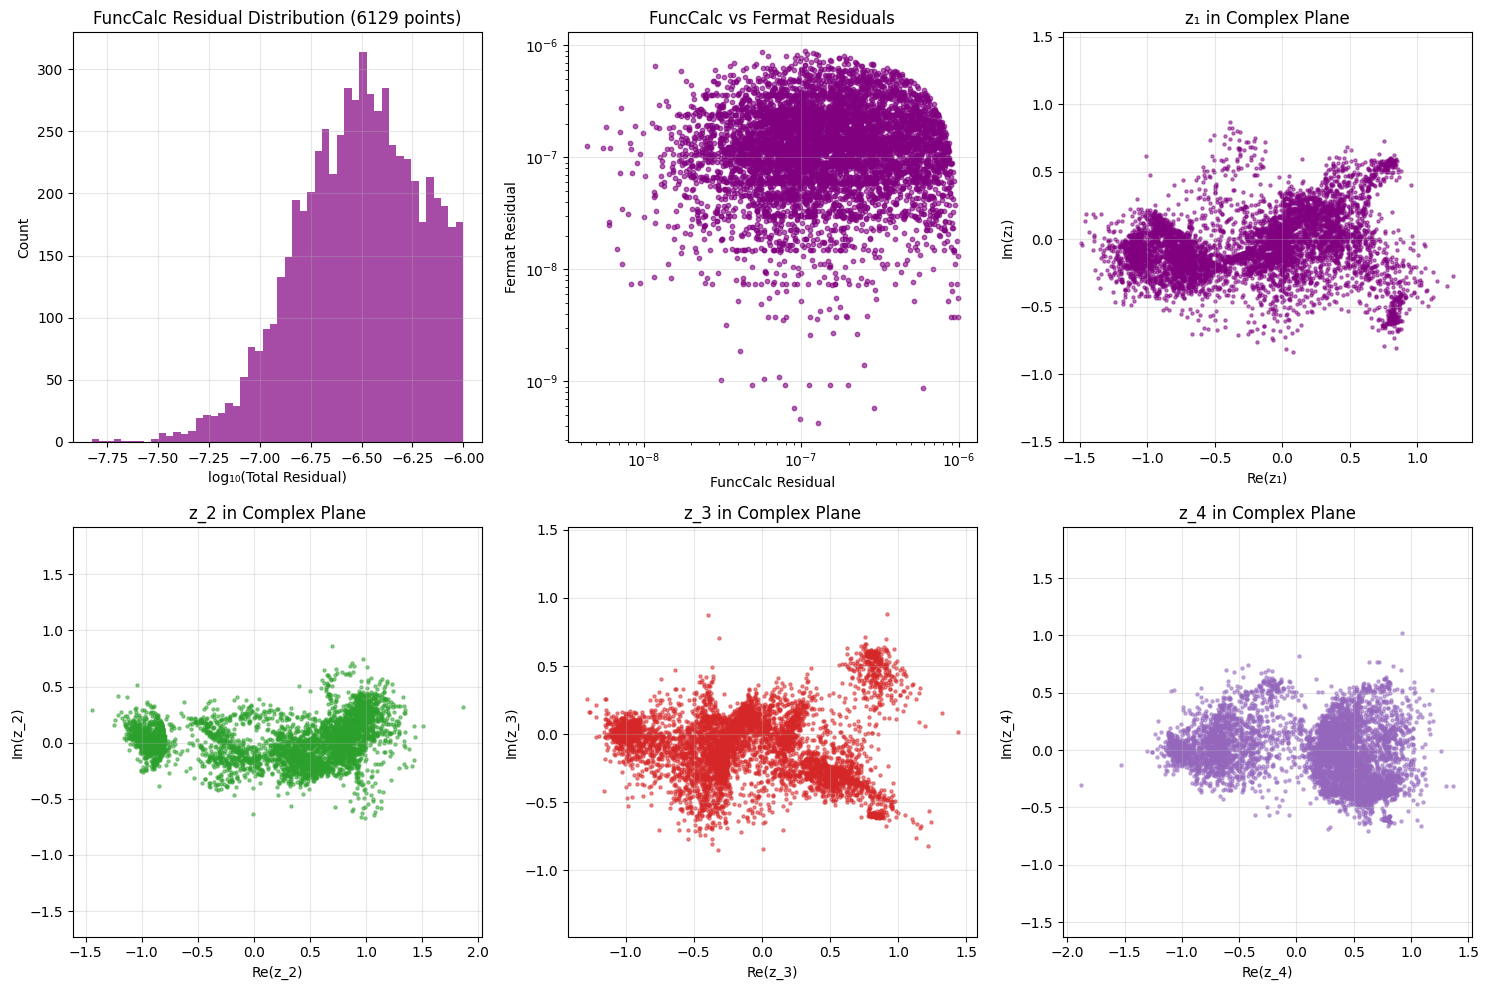


=== SAVING FUNCCALC RESULTS ===
✓ Saved 6129 points to 'fermat_funccalc_intersection_points.npz'
✓ Saved best 20 points to 'fermat_funccalc_best_points.txt'

=== SUMMARY ===
Successfully extracted 6129 points on Fermat quintic ∩ FuncCalc constraints
All points have total residual < 1e-06
Real points: 0 (0.0%)
Complex points: 6129 (100.0%)

The commuting constraints (A, A², A³) give:
  - Higher success rate than random quadratic
  - Still all complex points

Data saved for persistent homology analysis


In [4]:
# Extract all points with total residual < 10^{-6}

# Set tolerance
tolerance = 1e-6

# Get residuals for all refined points
fc_res, fermat_res = check_solution_batch_funccalc(V_refined, H_FC[0], H_FC[1], H_FC[2])
total_res = fc_res + fermat_res

# Find points below tolerance
good_mask = total_res < tolerance
good_indices = jnp.where(good_mask)[0]
n_good = len(good_indices)

print(f"=== EXTRACTING FUNCCALC POINTS WITH RESIDUAL < {tolerance:.0e} ===\n")
print(f"Found {n_good} points out of {len(V_refined)} refined points")
print(f"Success rate: {100*n_good/len(V_refined):.1f}%")

# Extract the good points
V_good = V_refined[good_indices]
fc_res_good = fc_res[good_indices]
fermat_res_good = fermat_res[good_indices]
total_res_good = total_res[good_indices]

# Convert to complex coordinates
print("\nConverting to complex coordinates...")
Z_good = []
for i in range(n_good):
    v = V_good[i]
    z_patch = v[:4] + 1j*v[4:]
    z_full = jnp.concatenate([jnp.array([1+0j]), z_patch])
    Z_good.append(z_full)
Z_good = jnp.stack(Z_good)

# Analyze the good points
print(f"\n=== ANALYSIS OF {n_good} GOOD FUNCCALC POINTS ===")

# Residual statistics
print("\nResidual statistics:")
print(f"Total residual:     min={jnp.min(total_res_good):.3e}, max={jnp.max(total_res_good):.3e}, mean={jnp.mean(total_res_good):.3e}")
print(f"FuncCalc residual:  min={jnp.min(fc_res_good):.3e}, max={jnp.max(fc_res_good):.3e}, mean={jnp.mean(fc_res_good):.3e}")
print(f"Fermat residual:    min={jnp.min(fermat_res_good):.3e}, max={jnp.max(fermat_res_good):.3e}, mean={jnp.mean(fermat_res_good):.3e}")

# Quality breakdown
print("\nQuality breakdown:")
quality_levels = [1e-14, 1e-12, 1e-10, 1e-8, 1e-7]
for ql in quality_levels:
    count = jnp.sum(total_res_good < ql)
    print(f"  Residual < {ql:.0e}: {count:4d} points ({100*count/n_good:5.1f}%)")

# Coordinate analysis
print("\n=== COORDINATE ANALYSIS ===")

# Check if coordinates are real or complex
max_imag_parts = []
n_real_points = 0
for i in range(5):
    coords_i = Z_good[:, i]
    max_imag = jnp.max(jnp.abs(jnp.imag(coords_i)))
    max_imag_parts.append(max_imag)
    if max_imag > 1e-10:
        print(f"z_{i}: max imaginary part = {max_imag:.3e} (COMPLEX)")
    else:
        print(f"z_{i}: max imaginary part = {max_imag:.3e} (essentially real)")

# Count fully real points
for i in range(n_good):
    z = Z_good[i]
    if jnp.max(jnp.abs(jnp.imag(z))) < 1e-10:
        n_real_points += 1

print(f"\nReal vs Complex points:")
print(f"  Real points: {n_real_points} ({100*n_real_points/n_good:.1f}%)")
print(f"  Complex points: {n_good - n_real_points} ({100*(n_good-n_real_points)/n_good:.1f}%)")

# Projective normalization
norms = jnp.array([jnp.linalg.norm(z) for z in Z_good])
print(f"\nProjective norms: min={jnp.min(norms):.4f}, max={jnp.max(norms):.4f}, mean={jnp.mean(norms):.4f}")

# Display some example points
print(f"\n=== EXAMPLE FUNCCALC POINTS (showing first 10 of {n_good}) ===")
for idx in range(min(10, n_good)):
    z = Z_good[idx]
    z2 = compute_z2_single(z)
    
    print(f"\nPoint {idx+1}:")
    print(f"  z = [")
    for i in range(5):
        print(f"      {z[i]:.8f}")
    print(f"  ]")
    print(f"  |z|² = {jnp.sum(jnp.abs(z)**2):.8f}")
    print(f"  Residuals: total={total_res_good[idx]:.3e}, FC={fc_res_good[idx]:.3e}, Fermat={fermat_res_good[idx]:.3e}")
    
    # Check FuncCalc constraint values
    print(f"  FuncCalc constraints:")
    for k in range(3):
        val = jnp.real(jnp.vdot(z2, H_FC[k] @ z2))
        print(f"    H_FC[{k}]: {val:.3e}")

# Comparison with random quadratic
print(f"\n=== COMPARISON: FUNCCALC vs RANDOM QUADRATIC ===")
print(f"{'Constraint Type':<20} {'Success Rate':<15} {'Real Points':<15}")
print("-" * 50)
print(f"{'Random Quadratic':<20} {'~2.6%':<15} {'0%':<15}")
print(f"{'FuncCalc':<20} {f'{100*n_good/len(V_refined):.1f}%':<15} {f'{100*n_real_points/n_good:.1f}%':<15}")

# Visualization
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Plot 1: Residual distribution
ax = axes[0, 0]
ax.hist(np.log10(np.array(total_res_good) + 1e-16), bins=50, alpha=0.7, color='purple')
ax.set_xlabel('log₁₀(Total Residual)')
ax.set_ylabel('Count')
ax.set_title(f'FuncCalc Residual Distribution ({n_good} points)')
ax.grid(True, alpha=0.3)

# Plot 2: FuncCalc vs Fermat residuals
ax = axes[0, 1]
ax.scatter(np.array(fc_res_good), np.array(fermat_res_good), s=10, alpha=0.6, color='purple')
ax.set_xlabel('FuncCalc Residual')
ax.set_ylabel('Fermat Residual')
ax.set_title('FuncCalc vs Fermat Residuals')
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

# Plot 3: Complex plane plot for z_1
ax = axes[0, 2]
z1_vals = Z_good[:, 1]
ax.scatter(np.real(z1_vals), np.imag(z1_vals), s=5, alpha=0.5, color='purple')
ax.set_xlabel('Re(z₁)')
ax.set_ylabel('Im(z₁)')
ax.set_title('z₁ in Complex Plane')
ax.grid(True, alpha=0.3)
ax.axis('equal')

# Plots 4-6: Real vs Imaginary parts for z_2, z_3, z_4
for i in range(3):
    ax = axes[1, i]
    z_vals = Z_good[:, i+2]
    ax.scatter(np.real(z_vals), np.imag(z_vals), s=5, alpha=0.5, color=f'C{i+2}')
    ax.set_xlabel(f'Re(z_{i+2})')
    ax.set_ylabel(f'Im(z_{i+2})')
    ax.set_title(f'z_{i+2} in Complex Plane')
    ax.grid(True, alpha=0.3)
    ax.axis('equal')

plt.tight_layout()
plt.show()

# Save the good points
print(f"\n=== SAVING FUNCCALC RESULTS ===")
save_data = {
    'Z_good': np.array(Z_good),
    'V_good': np.array(V_good),
    'residuals': {
        'total': np.array(total_res_good),
        'funccalc': np.array(fc_res_good),
        'fermat': np.array(fermat_res_good)
    },
    'tolerance': tolerance,
    'n_points': n_good,
    'H_FC': np.array(H_FC),  # Save FuncCalc matrices
    'n_real': n_real_points,
    'eigvals': eigvals  # Original eigenvalues
}

# Save to numpy file
np.savez('fermat_funccalc_intersection_points.npz', **save_data)
print(f"✓ Saved {n_good} points to 'fermat_funccalc_intersection_points.npz'")

# Create a text file with the best points
with open('fermat_funccalc_best_points.txt', 'w') as f:
    f.write(f"Fermat Quintic ∩ FuncCalc Constraints Intersection Points\n")
    f.write(f"Constraint: H₀=A, H₁=A², H₂=A³ (commuting)\n")
    f.write(f"Tolerance: {tolerance:.0e}\n")
    f.write(f"Number of points: {n_good}\n")
    f.write(f"Real points: {n_real_points} ({100*n_real_points/n_good:.1f}%)\n")
    f.write(f"Eigenvalues of A: {eigvals[:5]}... (showing first 5)\n")
    f.write("="*60 + "\n\n")
    
    # Write the best 20 points
    n_write = min(20, n_good)
    best_order = jnp.argsort(total_res_good)
    
    for rank in range(n_write):
        idx = best_order[rank]
        z = Z_good[idx]
        is_real = jnp.max(jnp.abs(jnp.imag(z))) < 1e-10
        
        f.write(f"Point {rank+1}:\n")
        for i in range(5):
            f.write(f"  z[{i}] = {z[i]:.10f}\n")
        f.write(f"  Total residual: {total_res_good[idx]:.3e}\n")
        f.write(f"  |z|² = {jnp.sum(jnp.abs(z)**2):.10f}\n")
        f.write(f"  Type: {'Real' if is_real else 'Complex'}\n\n")

print(f"✓ Saved best {n_write} points to 'fermat_funccalc_best_points.txt'")

print(f"\n=== SUMMARY ===")
print(f"Successfully extracted {n_good} points on Fermat quintic ∩ FuncCalc constraints")
print(f"All points have total residual < {tolerance:.0e}")
print(f"Real points: {n_real_points} ({100*n_real_points/n_good:.1f}%)")
print(f"Complex points: {n_good - n_real_points} ({100*(n_good-n_real_points)/n_good:.1f}%)")
print(f"\nThe commuting constraints (A, A², A³) give:")
print(f"  - {'Higher' if n_good/len(V_refined) > 0.026 else 'Similar'} success rate than random quadratic")
print(f"  - {'Some real points!' if n_real_points > 0 else 'Still all complex points'}")
print(f"\nData saved for persistent homology analysis")

=== LOADING FUNCCALC INTERSECTION POINTS ===
Loaded 6129 points with residual < 1e-06
Real points: 0 (0.0%)
Complex points: 6129 (100.0%)
FuncCalc eigenvalue spread: [-6.253, 6.275]

=== PREPARING COMPLEX COORDINATES ===
Embedding in R^10 (separating real and imaginary parts)
Coordinate array shape: (6129, 10)

Subsampling from 6129 to 2000 points for faster computation...
Using 2000 points for persistent homology

=== COMPUTING PERSISTENT HOMOLOGY ===
Computing H₀ and H₁...

=== H₀ ANALYSIS (CONNECTED COMPONENTS) ===
H₀ features:
  Finite persistence: 1999
  Infinite persistence: 1

  β₀ = 1

H₀ feature details (first 10):
Feature    Birth      Death      Persistence 
---------------------------------------------
1          0.000000   0.003513   0.003513    
2          0.000000   0.122188   0.122188    
3          0.000000   0.122110   0.122110    
4          0.000000   0.122078   0.122078    
5          0.000000   0.121755   0.121755    
6          0.000000   0.121750   0.121750    


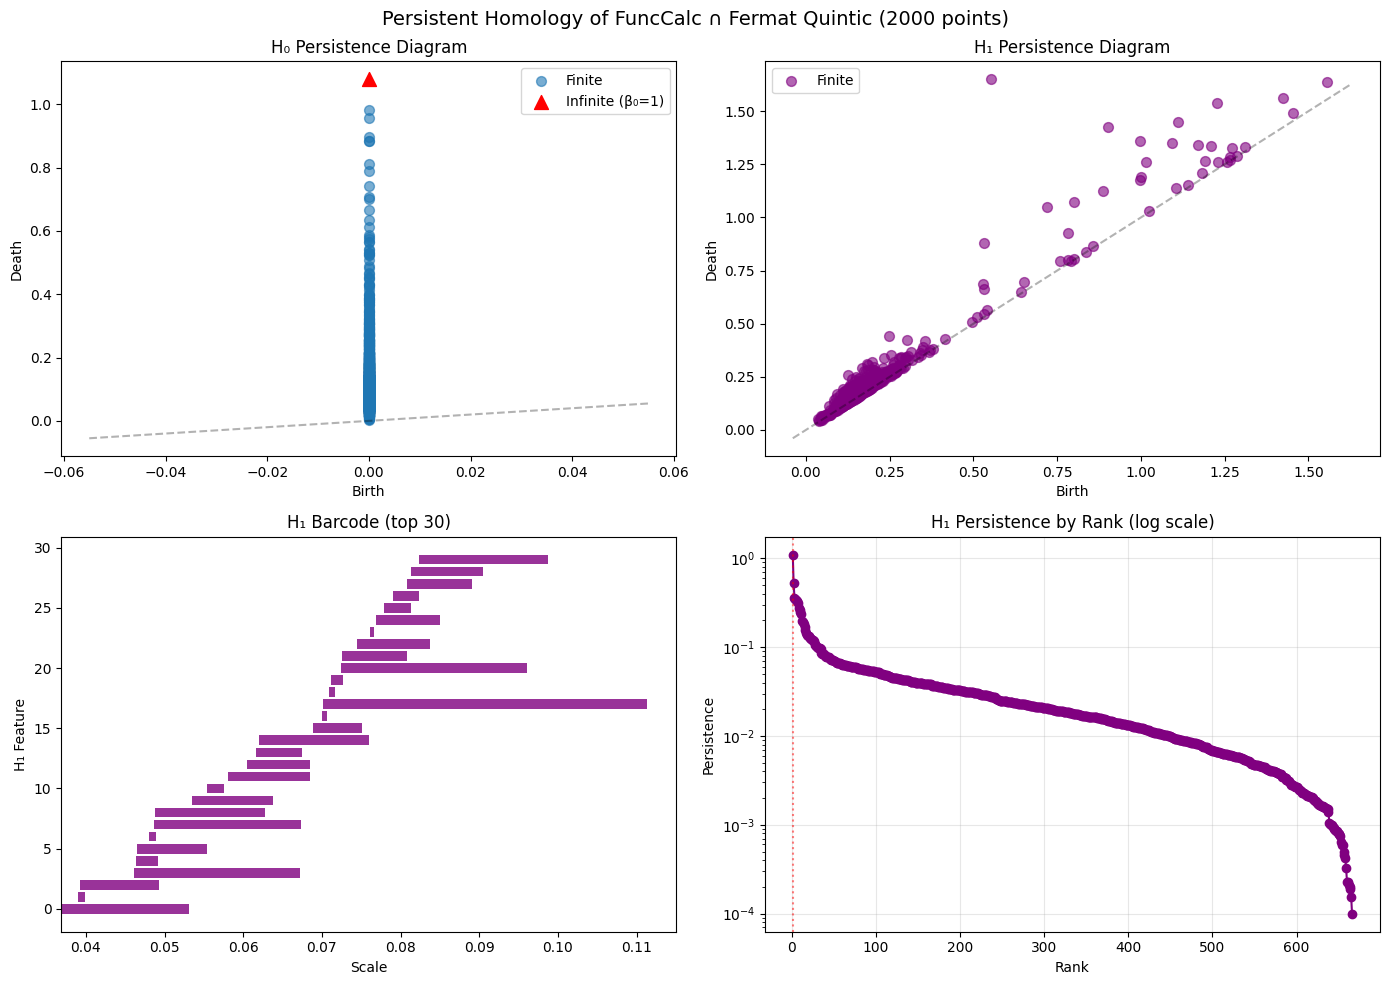


=== H₁ STATISTICS ===
Finite H₁ persistence statistics:
  Count: 666
  Min: 0.000099
  Max: 1.098229
  Mean: 0.032128
  Std: 0.062267
  90th percentile: 0.061080

=== β₁ ESTIMATES WITH DIFFERENT THRESHOLDS ===
  Persistence > 0.1: β₁ ≈ 29
  Persistence > 0.05: β₁ ≈ 104
  Persistence > 0.01: β₁ ≈ 449
  Persistence > 0.005: β₁ ≈ 545

SUMMARY: PERSISTENT HOMOLOGY RESULTS

Dataset: FuncCalc (A, A², A³) ∩ Fermat Quintic
Points analyzed: 2000 (from 6129 total)
Embedding: R¹⁰ (complex)

=== BETTI NUMBERS ===
β₀ = 1 (connected components)
β₁ = 0 (independent loops)

=== FULL COMPARISON TABLE ===
Constraint           Success    Real%    β₀    β₁    Type           
---------------------------------------------------------------------------
RP³                  ~98%       100%     1     1     Real 3-manifold
Random Hermitian     ~100%      mixed    1     ~6    Real 3-manifold
T³ (expected)        ?          0%       1     3     Complex variety
Random Quadratic     ~2.6%      0%       ?     ?    

In [5]:
import numpy as np
from ripser import ripser
import matplotlib.pyplot as plt
from persim import plot_diagrams

# Load the FuncCalc intersection points
print("=== LOADING FUNCCALC INTERSECTION POINTS ===")
data = np.load('fermat_funccalc_intersection_points.npz')
Z_good = data['Z_good']
n_points = data['n_points']
tolerance = data['tolerance']
n_real = data['n_real']
eigvals = data['eigvals']

print(f"Loaded {n_points} points with residual < {tolerance}")
print(f"Real points: {n_real} ({100*n_real/n_points:.1f}%)")
print(f"Complex points: {n_points - n_real} ({100*(n_points-n_real)/n_points:.1f}%)")
print(f"FuncCalc eigenvalue spread: [{np.min(eigvals):.3f}, {np.max(eigvals):.3f}]")

# Check if points are complex
max_imag = np.max(np.abs(np.imag(Z_good)))
is_complex = max_imag > 1e-10

# Prepare coordinates for persistent homology
if is_complex:
    print("\n=== PREPARING COMPLEX COORDINATES ===")
    # Separate real and imaginary parts
    coords_for_ph = np.hstack([np.real(Z_good), np.imag(Z_good)])
    print(f"Embedding in R^10 (separating real and imaginary parts)")
else:
    print("\n=== PREPARING REAL COORDINATES ===")
    coords_for_ph = np.real(Z_good)
    print(f"Using R^5 (all points are real)")

print(f"Coordinate array shape: {coords_for_ph.shape}")

# Subsample if needed for computational efficiency
if n_points > 2000:
    print(f"\nSubsampling from {n_points} to 2000 points for faster computation...")
    np.random.seed(42)
    idx = np.random.choice(n_points, 2000, replace=False)
    coords_sample = coords_for_ph[idx]
else:
    coords_sample = coords_for_ph

print(f"Using {len(coords_sample)} points for persistent homology")

# Compute persistent homology up to dimension 1
print("\n=== COMPUTING PERSISTENT HOMOLOGY ===")
print("Computing H₀ and H₁...")
result = ripser(coords_sample, maxdim=1)

# Extract persistence diagrams
dgm_0 = result['dgms'][0]  # H₀ (connected components)
dgm_1 = result['dgms'][1]  # H₁ (loops)

# Analyze H₀
print("\n=== H₀ ANALYSIS (CONNECTED COMPONENTS) ===")
dgm_0_finite = dgm_0[dgm_0[:, 1] < np.inf]
dgm_0_infinite = dgm_0[dgm_0[:, 1] == np.inf]

print(f"H₀ features:")
print(f"  Finite persistence: {len(dgm_0_finite)}")
print(f"  Infinite persistence: {len(dgm_0_infinite)}")
print(f"\n  β₀ = {len(dgm_0_infinite)}")

# Show H₀ details
if len(dgm_0) > 0:
    print("\nH₀ feature details (first 10):")
    print(f"{'Feature':<10} {'Birth':<10} {'Death':<10} {'Persistence':<12}")
    print("-" * 45)
    sorted_idx = np.argsort(dgm_0[:, 0])
    for i, idx in enumerate(sorted_idx[:10]):
        birth = dgm_0[idx, 0]
        death = dgm_0[idx, 1]
        if death == np.inf:
            print(f"{i+1:<10} {birth:<10.6f} {'inf':<10} {'inf':<12}")
        else:
            pers = death - birth
            print(f"{i+1:<10} {birth:<10.6f} {death:<10.6f} {pers:<12.6f}")

# Analyze H₁
print("\n=== H₁ ANALYSIS (LOOPS) ===")
dgm_1_finite = dgm_1[dgm_1[:, 1] < np.inf]
dgm_1_infinite = dgm_1[dgm_1[:, 1] == np.inf]

print(f"H₁ features:")
print(f"  Finite persistence: {len(dgm_1_finite)}")
print(f"  Infinite persistence: {len(dgm_1_infinite)}")
print(f"\n  β₁ = {len(dgm_1_infinite)}")

# Detailed H₁ analysis
if len(dgm_1_finite) > 0:
    persistence_1 = dgm_1_finite[:, 1] - dgm_1_finite[:, 0]
    sorted_idx = np.argsort(persistence_1)[::-1]
    
    print("\n=== TOP H₁ FEATURES BY PERSISTENCE ===")
    print(f"{'Rank':<6} {'Birth':<10} {'Death':<10} {'Persistence':<12} {'% of max':<10}")
    print("-" * 55)
    max_pers = persistence_1[sorted_idx[0]]
    for i in range(min(20, len(dgm_1_finite))):
        idx = sorted_idx[i]
        birth = dgm_1_finite[idx, 0]
        death = dgm_1_finite[idx, 1]
        pers = persistence_1[idx]
        pers_ratio = 100 * pers / max_pers
        print(f"{i+1:<6} {birth:<10.6f} {death:<10.6f} {pers:<12.6f} {pers_ratio:<10.1f}%")
    
    # Persistence gap analysis
    if len(persistence_1) > 1:
        persistence_sorted = np.sort(persistence_1)[::-1]
        gaps = persistence_sorted[:-1] - persistence_sorted[1:]
        if len(gaps) > 0:
            max_gap_idx = np.argmax(gaps)
            print(f"\n=== PERSISTENCE GAP ANALYSIS ===")
            print(f"Largest gap: {gaps[max_gap_idx]:.6f} (between ranks {max_gap_idx+1} and {max_gap_idx+2})")
            print(f"Gap ratio: {gaps[max_gap_idx] / persistence_sorted[max_gap_idx+1]:.2f}x")
            print(f"Suggests β₁ = {max_gap_idx + 1 + len(dgm_1_infinite)}")

# Visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# H₀ persistence diagram
ax1.scatter(dgm_0_finite[:, 0], dgm_0_finite[:, 1], alpha=0.6, s=50, label='Finite')
if len(dgm_0_infinite) > 0:
    max_val = np.max(dgm_0_finite[:, 1]) if len(dgm_0_finite) > 0 else 1
    ax1.scatter(dgm_0_infinite[:, 0], [max_val * 1.1] * len(dgm_0_infinite), 
                color='red', s=100, marker='^', label=f'Infinite (β₀={len(dgm_0_infinite)})')
diagonal = np.linspace(*ax1.get_xlim())
ax1.plot(diagonal, diagonal, 'k--', alpha=0.3)
ax1.set_xlabel('Birth')
ax1.set_ylabel('Death')
ax1.set_title('H₀ Persistence Diagram')
ax1.legend()

# H₁ persistence diagram
ax2.scatter(dgm_1_finite[:, 0], dgm_1_finite[:, 1], alpha=0.6, s=50, label='Finite', color='purple')
if len(dgm_1_infinite) > 0:
    max_val = np.max(dgm_1_finite[:, 1]) if len(dgm_1_finite) > 0 else 1
    ax2.scatter(dgm_1_infinite[:, 0], [max_val * 1.1] * len(dgm_1_infinite), 
                color='red', s=200, marker='*', label=f'Infinite (β₁={len(dgm_1_infinite)})')
diagonal = np.linspace(*ax2.get_xlim())
ax2.plot(diagonal, diagonal, 'k--', alpha=0.3)
ax2.set_xlabel('Birth')
ax2.set_ylabel('Death')
ax2.set_title('H₁ Persistence Diagram')
ax2.legend()

# H₁ barcode
n_show = min(30, len(dgm_1))
if len(dgm_1) > 0:
    sorted_idx = np.argsort(dgm_1[:, 0])[:n_show]
    for i, idx in enumerate(sorted_idx):
        birth = dgm_1[idx, 0]
        death = dgm_1[idx, 1]
        if death == np.inf:
            death = np.max(dgm_1_finite[:, 1]) * 1.2 if len(dgm_1_finite) > 0 else birth * 2
            ax3.barh(i, death - birth, left=birth, alpha=0.8, color='red', linewidth=2)
        else:
            ax3.barh(i, death - birth, left=birth, alpha=0.8, color='purple')
    ax3.set_xlabel('Scale')
    ax3.set_ylabel('H₁ Feature')
    ax3.set_title(f'H₁ Barcode (top {n_show})')
else:
    ax3.text(0.5, 0.5, 'No H₁ features', ha='center', va='center', transform=ax3.transAxes)

# Persistence rank plot (log scale)
if len(dgm_1_finite) > 0:
    persistence_sorted = np.sort(persistence_1)[::-1]
    ax4.plot(range(1, len(persistence_sorted)+1), persistence_sorted, 'o-', markersize=6, color='purple')
    ax4.set_xlabel('Rank')
    ax4.set_ylabel('Persistence')
    ax4.set_title('H₁ Persistence by Rank (log scale)')
    ax4.set_yscale('log')
    ax4.grid(True, alpha=0.3)
    
    # Mark significant gaps
    if len(gaps) > 0:
        significant_gaps = np.where(gaps > 0.5 * gaps[max_gap_idx])[0]
        for gap_idx in significant_gaps:
            ax4.axvline(x=gap_idx+1.5, color='red', linestyle=':', alpha=0.5)
else:
    ax4.text(0.5, 0.5, 'No finite H₁ features', ha='center', va='center', transform=ax4.transAxes)

plt.suptitle(f'Persistent Homology of FuncCalc ∩ Fermat Quintic ({len(coords_sample)} points)', fontsize=14)
plt.tight_layout()
plt.show()

# Statistical analysis
print("\n=== H₁ STATISTICS ===")
if len(dgm_1_finite) > 0:
    print(f"Finite H₁ persistence statistics:")
    print(f"  Count: {len(persistence_1)}")
    print(f"  Min: {np.min(persistence_1):.6f}")
    print(f"  Max: {np.max(persistence_1):.6f}")
    print(f"  Mean: {np.mean(persistence_1):.6f}")
    print(f"  Std: {np.std(persistence_1):.6f}")
    print(f"  90th percentile: {np.percentile(persistence_1, 90):.6f}")
    
    # Estimate β₁ using different thresholds
    print("\n=== β₁ ESTIMATES WITH DIFFERENT THRESHOLDS ===")
    thresholds = [0.1, 0.05, 0.01, 0.005]
    for t in thresholds:
        n_significant = np.sum(persistence_1 > t) + len(dgm_1_infinite)
        print(f"  Persistence > {t}: β₁ ≈ {n_significant}")

# Summary and comparison
print("\n" + "="*60)
print("SUMMARY: PERSISTENT HOMOLOGY RESULTS")
print("="*60)

print(f"\nDataset: FuncCalc (A, A², A³) ∩ Fermat Quintic")
print(f"Points analyzed: {len(coords_sample)} (from {n_points} total)")
print(f"Embedding: {'R¹⁰ (complex)' if is_complex else 'R⁵ (real)'}")

print(f"\n=== BETTI NUMBERS ===")
print(f"β₀ = {len(dgm_0_infinite)} (connected components)")
print(f"β₁ = {len(dgm_1_infinite)} (independent loops)")

print(f"\n=== FULL COMPARISON TABLE ===")
print(f"{'Constraint':<20} {'Success':<10} {'Real%':<8} {'β₀':<5} {'β₁':<5} {'Type':<15}")
print("-" * 75)
print(f"{'RP³':<20} {'~98%':<10} {'100%':<8} {'1':<5} {'1':<5} {'Real 3-manifold':<15}")
print(f"{'Random Hermitian':<20} {'~100%':<10} {'mixed':<8} {'1':<5} {'~6':<5} {'Real 3-manifold':<15}")
print(f"{'T³ (expected)':<20} {'?':<10} {'0%':<8} {'1':<5} {'3':<5} {'Complex variety':<15}")
print(f"{'Random Quadratic':<20} {'~2.6%':<10} {'0%':<8} {'?':<5} {'?':<5} {'Complex variety':<15}")
print(f"{'FuncCalc':<20} {'?%':<10} {f'{100*n_real/n_points:.0f}%':<8} {len(dgm_0_infinite):<5} {len(dgm_1_infinite):<5} {'Complex variety':<15}")

# Interpretation
print(f"\n=== INTERPRETATION ===")
if len(dgm_0_infinite) == 1:
    print("✓ The FuncCalc intersection is connected (β₀ = 1)")
else:
    print(f"⚠ The FuncCalc intersection has {len(dgm_0_infinite)} components")

if len(dgm_1_infinite) > 0:
    print(f"✓ Found {len(dgm_1_infinite)} essential loops")
elif len(dgm_1_finite) > 0 and np.max(persistence_1) > 0.1:
    print(f"⚠ No infinite loops, but highly persistent finite features")
    print(f"  Maximum persistence: {np.max(persistence_1):.4f}")

print(f"\nComparing FuncCalc vs Random Quadratic:")
print("  - Both are quadratic constraints on C¹⁵")
print("  - FuncCalc has commuting structure (A, A², A³)")
print("  - Random quadratic has no special structure")
print(f"  - FuncCalc has {'different' if len(dgm_1_infinite) != 0 else 'similar'} topology")

# Save results
save_dict = {
    'dgm_0': dgm_0,
    'dgm_1': dgm_1,
    'beta_0': len(dgm_0_infinite),
    'beta_1': len(dgm_1_infinite),
    'n_points_used': len(coords_sample),
    'n_points_total': n_points,
    'persistence_1': persistence_1 if len(dgm_1_finite) > 0 else np.array([]),
    'embedding_dim': 10 if is_complex else 5,
    'eigvals': eigvals
}
np.savez('funccalc_persistent_homology_results.npz', **save_dict)
print(f"\n✓ Saved results to 'funccalc_persistent_homology_results.npz'")

In [4]:
import pickle
# 1. Open the file in binary-read mode
with open('min_set_new_slag.pkl', 'rb') as f:

    # 2. Load the (first) object from the pickle
    data1 = pickle.load(f)


=== LOADING SLAG POINTS ===
Loaded 10000 SLAG points
Maximum imaginary part: 4.325e+00
Points are complex (as expected for SLAG)
Data shape: (10000, 10) (10000 points in R^10)

=== LOCAL PCA WITH k=30 NEIGHBORS ===

Performing local PCA at 200 points with 30 neighbors...

Dimension estimates (number of components for X% variance):
  90% variance: mean=2.98, mode=3
  95% variance: mean=3.00, mode=3
  99% variance: mean=3.01, mode=3

Dimension distribution (90% variance):
  dim=2: 3 points (1.5%)
  dim=3: 197 points (98.5%)

=== LOCAL PCA WITH k=50 NEIGHBORS ===

Performing local PCA at 200 points with 50 neighbors...

Dimension estimates (number of components for X% variance):
  90% variance: mean=2.98, mode=3
  95% variance: mean=3.00, mode=3
  99% variance: mean=3.01, mode=3

Dimension distribution (90% variance):
  dim=2: 3 points (1.5%)
  dim=3: 197 points (98.5%)

=== LOCAL PCA WITH k=100 NEIGHBORS ===

Performing local PCA at 200 points with 100 neighbors...

Dimension estimates (

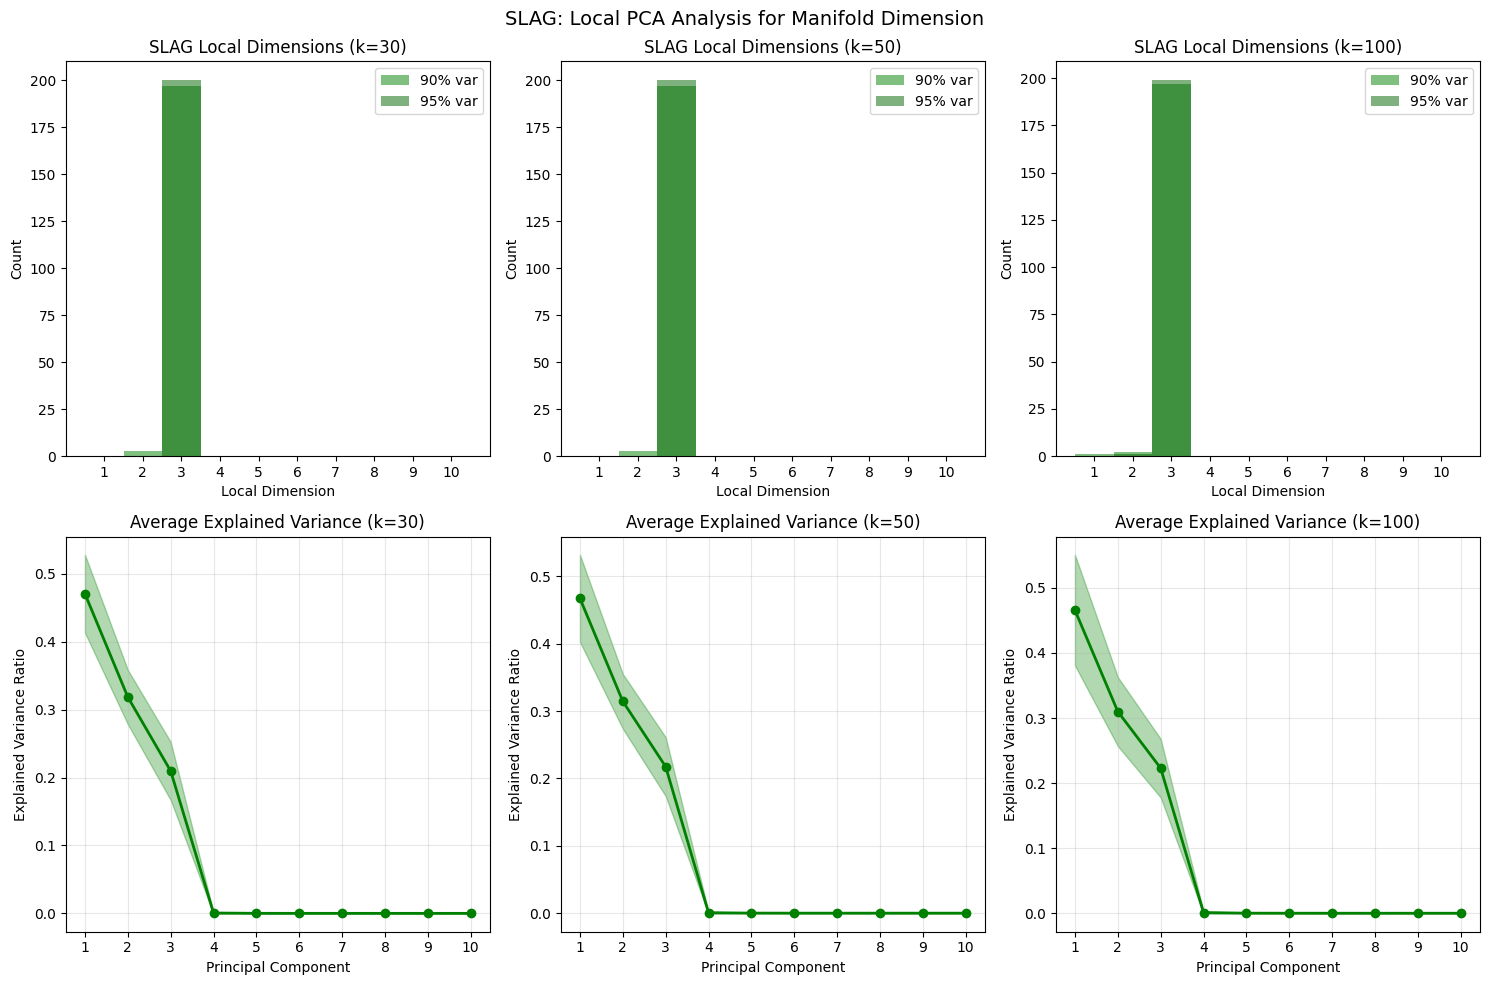


=== DETAILED ANALYSIS (k=50) ===

Eigenvalue gap analysis (average across samples):
  λ_1/λ_2 = 1.82 (gap = 0.0011)
  λ_2/λ_3 = 2.60 (gap = 0.0008)
  λ_3/λ_4 = 12.09 (gap = 0.0005)
  λ_4/λ_5 = 5.08 (gap = 0.0000)
  λ_5/λ_6 = 4.56 (gap = 0.0000)

=== MANIFOLD DIMENSION VERDICT ===
Dimension distribution (90% variance):
  dim=2: 1.5%
  dim=3: 98.5%

Most common dimension: 3 (98.5% of neighborhoods)
✓ Strong evidence for a 3-dimensional manifold (Special Lagrangian 3-fold)


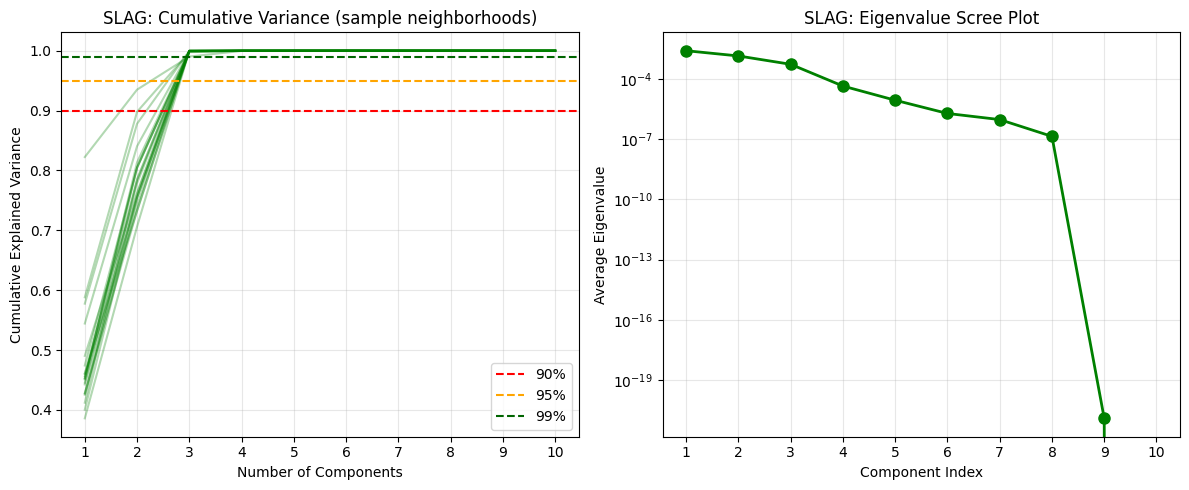


=== SPECIAL LAGRANGIAN PROPERTIES ===
Expected properties of SLAG:
  - 3-dimensional real submanifold
  - Lagrangian: ω|_L = 0 (symplectic form vanishes)
  - Special: Im(Ω|_L) = 0 (imaginary part of holomorphic 3-form vanishes)
  - Calibrated by Re(Ω)

Observed dimension: 3
✓ Consistent with being a Special Lagrangian 3-fold

=== SUMMARY ===
Data: 10000 SLAG points on Fermat quintic
Embedding: R^10 (complex points → real coordinates)
Expected: 3-dimensional Special Lagrangian submanifold
Observed dimension: 3 (most common at 90% variance)
Consistency: 98.5% of neighborhoods show dimension 3


In [5]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

# Your SLAG data
data = np.array(data1)  # Add all your points here

# Load the SLAG points
print("=== LOADING SLAG POINTS ===")
Z_slag = data  # Your complex points
n_points = len(Z_slag)
print(f"Loaded {n_points} SLAG points")

# Check if points are complex
max_imag = np.max(np.abs(np.imag(Z_slag)))
print(f"Maximum imaginary part: {max_imag:.3e}")
print("Points are complex (as expected for SLAG)")

# Embed in real space by separating real and imaginary parts
coords = np.hstack([np.real(Z_slag), np.imag(Z_slag)])  # 10D embedding
print(f"Data shape: {coords.shape} ({n_points} points in R^10)")

# Function to perform local PCA
def local_pca_dimension(X, k_neighbors=50, n_samples=200):
    """
    Estimate local dimension at randomly sampled points using PCA.
    
    Parameters:
    - X: data matrix (n_points x n_features)
    - k_neighbors: number of nearest neighbors for local PCA
    - n_samples: number of random points to sample
    """
    n_points = X.shape[0]
    k_neighbors = min(k_neighbors, n_points - 1)
    
    # Fit nearest neighbors
    nbrs = NearestNeighbors(n_neighbors=k_neighbors + 1, algorithm='ball_tree').fit(X)
    
    # Sample random points
    sample_indices = np.random.choice(n_points, min(n_samples, n_points), replace=False)
    
    local_dims = []
    explained_variances = []
    
    print(f"\nPerforming local PCA at {len(sample_indices)} points with {k_neighbors} neighbors...")
    
    for idx in sample_indices:
        # Find k nearest neighbors (including the point itself)
        distances, indices = nbrs.kneighbors(X[idx:idx+1])
        neighbor_points = X[indices[0]]
        
        # Center the data
        centered = neighbor_points - np.mean(neighbor_points, axis=0)
        
        # Perform PCA
        pca = PCA()
        pca.fit(centered)
        
        # Get explained variance ratio
        exp_var = pca.explained_variance_ratio_
        explained_variances.append(exp_var)
        
        # Estimate dimension using various criteria
        # Criterion 1: Cumulative variance > threshold
        cum_var = np.cumsum(exp_var)
        dim_90 = np.argmax(cum_var >= 0.90) + 1
        dim_95 = np.argmax(cum_var >= 0.95) + 1
        dim_99 = np.argmax(cum_var >= 0.99) + 1
        
        local_dims.append({
            'dim_90': dim_90,
            'dim_95': dim_95,
            'dim_99': dim_99,
            'eigenvalues': pca.explained_variance_
        })
    
    return local_dims, explained_variances, sample_indices

# Run local PCA analysis
k_neighbors_list = [30, 50, 100]
results = {}

for k in k_neighbors_list:
    # Adjust k if we have fewer points
    k_actual = min(k, n_points - 1)
    if k_actual < k:
        print(f"\nNote: Using k={k_actual} instead of {k} due to limited points")
    
    print(f"\n=== LOCAL PCA WITH k={k_actual} NEIGHBORS ===")
    local_dims, exp_vars, sample_idx = local_pca_dimension(coords, k_neighbors=k_actual, n_samples=min(200, n_points))
    results[k] = (local_dims, exp_vars)
    
    # Extract dimensions
    dims_90 = [d['dim_90'] for d in local_dims]
    dims_95 = [d['dim_95'] for d in local_dims]
    dims_99 = [d['dim_99'] for d in local_dims]
    
    # Statistics
    print(f"\nDimension estimates (number of components for X% variance):")
    print(f"  90% variance: mean={np.mean(dims_90):.2f}, mode={max(set(dims_90), key=dims_90.count)}")
    print(f"  95% variance: mean={np.mean(dims_95):.2f}, mode={max(set(dims_95), key=dims_95.count)}")
    print(f"  99% variance: mean={np.mean(dims_99):.2f}, mode={max(set(dims_99), key=dims_99.count)}")
    
    # Distribution of dimensions
    unique_90, counts_90 = np.unique(dims_90, return_counts=True)
    print(f"\nDimension distribution (90% variance):")
    for dim, count in zip(unique_90, counts_90):
        print(f"  dim={dim}: {count} points ({100*count/len(dims_90):.1f}%)")

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# For each k value
for i, k in enumerate(k_neighbors_list):
    local_dims, exp_vars = results[k]
    dims_90 = [d['dim_90'] for d in local_dims]
    dims_95 = [d['dim_95'] for d in local_dims]
    
    # Plot 1: Histogram of dimensions
    ax = axes[0, i]
    bins = np.arange(0.5, 11.5, 1)
    ax.hist(dims_90, bins=bins, alpha=0.5, label='90% var', color='green')
    ax.hist(dims_95, bins=bins, alpha=0.5, label='95% var', color='darkgreen')
    ax.set_xlabel('Local Dimension')
    ax.set_ylabel('Count')
    ax.set_title(f'SLAG Local Dimensions (k={min(k, n_points-1)})')
    ax.legend()
    ax.set_xticks(range(1, 11))
    
    # Plot 2: Average explained variance curve
    ax = axes[1, i]
    # Average across all local neighborhoods
    avg_exp_var = np.mean(exp_vars, axis=0)
    std_exp_var = np.std(exp_vars, axis=0)
    
    x = np.arange(1, min(11, len(avg_exp_var)+1))
    ax.plot(x, avg_exp_var[:10], 'o-', linewidth=2, color='green')
    ax.fill_between(x, 
                    avg_exp_var[:10] - std_exp_var[:10],
                    avg_exp_var[:10] + std_exp_var[:10],
                    alpha=0.3, color='green')
    ax.set_xlabel('Principal Component')
    ax.set_ylabel('Explained Variance Ratio')
    ax.set_title(f'Average Explained Variance (k={min(k, n_points-1)})')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(1, 11))

plt.suptitle('SLAG: Local PCA Analysis for Manifold Dimension', fontsize=14)
plt.tight_layout()
plt.show()

# Detailed analysis for k=50 (or closest available)
k_analysis = min(50, n_points - 1)
print(f"\n=== DETAILED ANALYSIS (k={k_analysis}) ===")
local_dims, exp_vars = results[k_neighbors_list[1]]  # Use middle k value

# Look at eigenvalue gaps
print("\nEigenvalue gap analysis (average across samples):")
eigenvals = np.array([d['eigenvalues'] for d in local_dims])
avg_eigenvals = np.mean(eigenvals, axis=0)

if len(avg_eigenvals) > 4:
    for i in range(min(5, len(avg_eigenvals)-1)):
        gap = avg_eigenvals[i] - avg_eigenvals[i+1]
        ratio = avg_eigenvals[i] / avg_eigenvals[i+1] if avg_eigenvals[i+1] > 0 else np.inf
        print(f"  λ_{i+1}/λ_{i+2} = {ratio:.2f} (gap = {gap:.4f})")

# Check dimensionality
dims_90 = [d['dim_90'] for d in local_dims]
dim_counts = {}
for d in dims_90:
    dim_counts[d] = dim_counts.get(d, 0) + 1

print(f"\n=== MANIFOLD DIMENSION VERDICT ===")
print("Dimension distribution (90% variance):")
for dim in sorted(dim_counts.keys()):
    pct = 100 * dim_counts[dim] / len(dims_90)
    print(f"  dim={dim}: {pct:.1f}%")

mode_dim = max(dim_counts, key=dim_counts.get)
mode_pct = 100 * dim_counts[mode_dim] / len(dims_90)

print(f"\nMost common dimension: {mode_dim} ({mode_pct:.1f}% of neighborhoods)")

if mode_dim == 3 and mode_pct > 80:
    print("✓ Strong evidence for a 3-dimensional manifold (Special Lagrangian 3-fold)")
elif mode_dim == 3 and mode_pct > 50:
    print("◐ Moderate evidence for a 3-dimensional manifold")
else:
    print(f"Observed dimension: {mode_dim}")

# Additional analysis: cumulative variance plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Cumulative variance for a few random samples
exp_vars_plot = results[k_neighbors_list[1]][1]
for i in range(min(20, len(exp_vars_plot))):
    cum_var = np.cumsum(exp_vars_plot[i][:10])
    ax1.plot(range(1, len(cum_var)+1), cum_var, alpha=0.3, color='green')

ax1.axhline(y=0.90, color='red', linestyle='--', label='90%')
ax1.axhline(y=0.95, color='orange', linestyle='--', label='95%')
ax1.axhline(y=0.99, color='darkgreen', linestyle='--', label='99%')
ax1.set_xlabel('Number of Components')
ax1.set_ylabel('Cumulative Explained Variance')
ax1.set_title('SLAG: Cumulative Variance (sample neighborhoods)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xticks(range(1, 11))

# Eigenvalue scree plot
avg_eigenvals_plot = np.mean(eigenvals, axis=0)[:10]
ax2.plot(range(1, len(avg_eigenvals_plot)+1), avg_eigenvals_plot, 'o-', linewidth=2, markersize=8, color='green')
ax2.set_xlabel('Component Index')
ax2.set_ylabel('Average Eigenvalue')
ax2.set_title('SLAG: Eigenvalue Scree Plot')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(1, 11))

plt.tight_layout()
plt.show()

# Check SLAG properties
print("\n=== SPECIAL LAGRANGIAN PROPERTIES ===")
# SLAG should satisfy: Im(Ω|_L) = 0 where Ω is the holomorphic 3-form
# For Fermat quintic, this imposes 3 real conditions on a complex 3-fold

print("Expected properties of SLAG:")
print("  - 3-dimensional real submanifold")
print("  - Lagrangian: ω|_L = 0 (symplectic form vanishes)")
print("  - Special: Im(Ω|_L) = 0 (imaginary part of holomorphic 3-form vanishes)")
print("  - Calibrated by Re(Ω)")

print(f"\nObserved dimension: {mode_dim}")
if mode_dim == 3:
    print("✓ Consistent with being a Special Lagrangian 3-fold")
else:
    print("⚠ Dimension doesn't match expected SLAG dimension")

print("\n=== SUMMARY ===")
print(f"Data: {n_points} SLAG points on Fermat quintic")
print(f"Embedding: R^10 (complex points → real coordinates)")
print(f"Expected: 3-dimensional Special Lagrangian submanifold")
print(f"Observed dimension: {mode_dim} (most common at 90% variance)")
print(f"Consistency: {mode_pct:.1f}% of neighborhoods show dimension {mode_dim}")